In [ ]:
# 2 Dimensi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
sns.set(rc={'figure.figsize':(20.7,8.27)})
sns.set_style("whitegrid")
sns.color_palette("dark")
plt.style.use("fivethirtyeight")

## Load Our Dataset

In [ ]:
df = pd.read_csv('berat_tinggi.csv')
df.head(3)

,tinggi,berat,deskripsi
0,158.114332,58.364240,Normal
1,160.344026,52.560155,Normal
2,161.486080,61.934852,Normal


In [ ]:
# merekomendasikan ukuran

<Axes: xlabel='berat', ylabel='tinggi'>

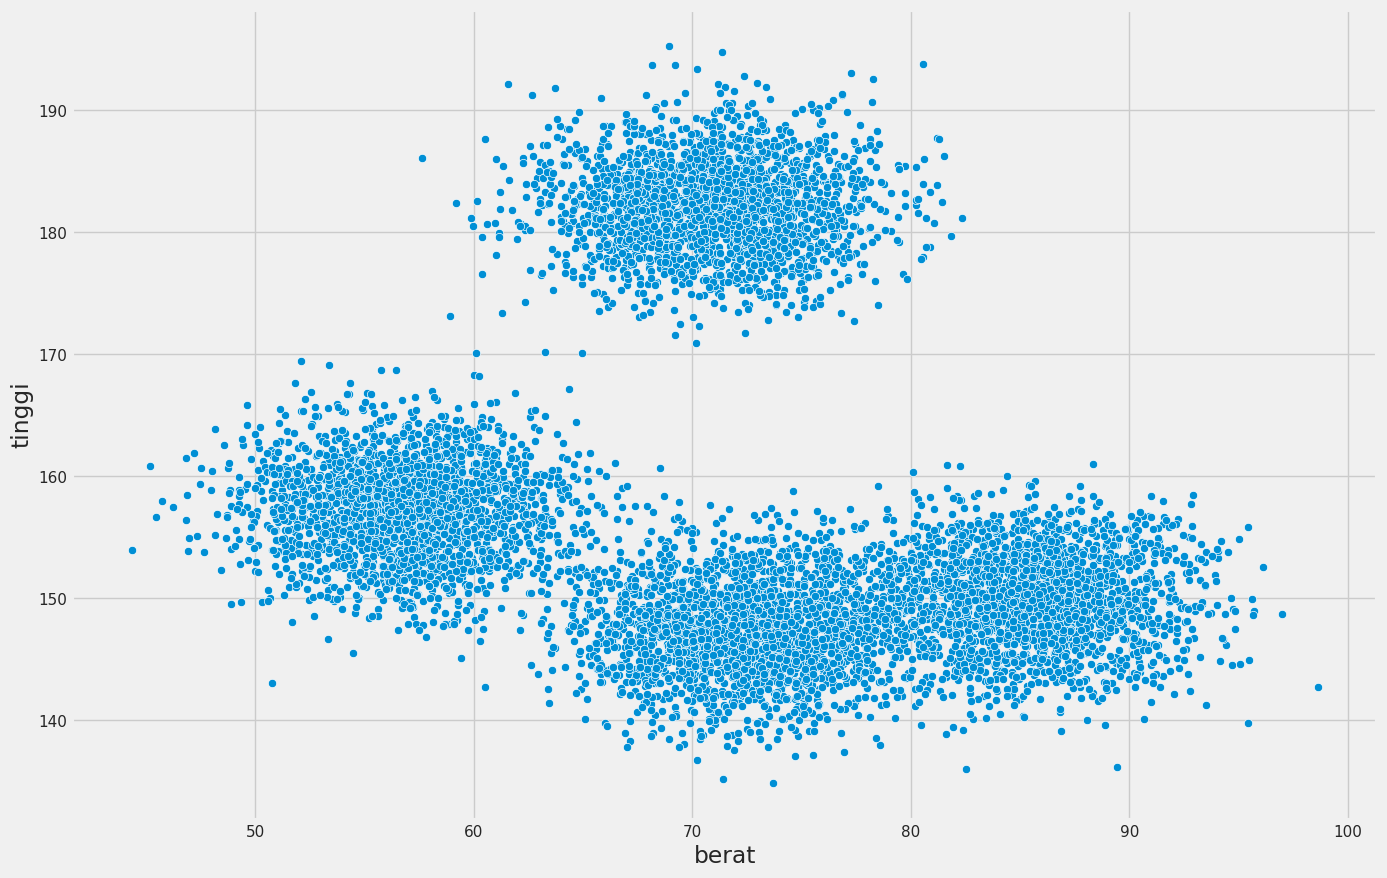

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')

## Standarisasi Fitur

In [ ]:
#krn ada hitungan jarak jd perlu di scallingkan

In [ ]:
feats = ['berat', 'tinggi']
X = df[feats].values
y = df['deskripsi'].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
new_df = pd.DataFrame(data = X_std, columns = feats)
new_df.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,3.785351e-16,-1.893375e-15
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


## Clustering

### Evaluasi/simulasi K-means

In [ ]:
# inertia

In [ ]:
from sklearn.cluster import KMeans
inertia = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(new_df.values)
  nilai_inertia = kmeans.inertia_
  inertia.append(nilai_inertia)
  print('jumlah cluster : ',i, 'nilai intertia : ', nilai_inertia)

jumlah cluster :  1 nilai intertia :  17775.99999999998
jumlah cluster :  2 nilai intertia :  8567.660451485932
jumlah cluster :  3 nilai intertia :  3222.51842248868
jumlah cluster :  4 nilai intertia :  1621.930649537243
jumlah cluster :  5 nilai intertia :  1443.266006762935
jumlah cluster :  6 nilai intertia :  1243.2874692531927
jumlah cluster :  7 nilai intertia :  1086.336552042899
jumlah cluster :  8 nilai intertia :  962.9556328248342
jumlah cluster :  9 nilai intertia :  900.004734040401
jumlah cluster :  10 nilai intertia :  840.6311842756218


In [ ]:
inertia

[17775.99999999998,
 8567.660451485932,
 3222.51842248868,
 1621.930649537243,
 1443.266006762935,
 1243.2874692531927,
 1086.336552042899,
 962.9556328248342,
 900.004734040401,
 840.6311842756218]

<Axes: >

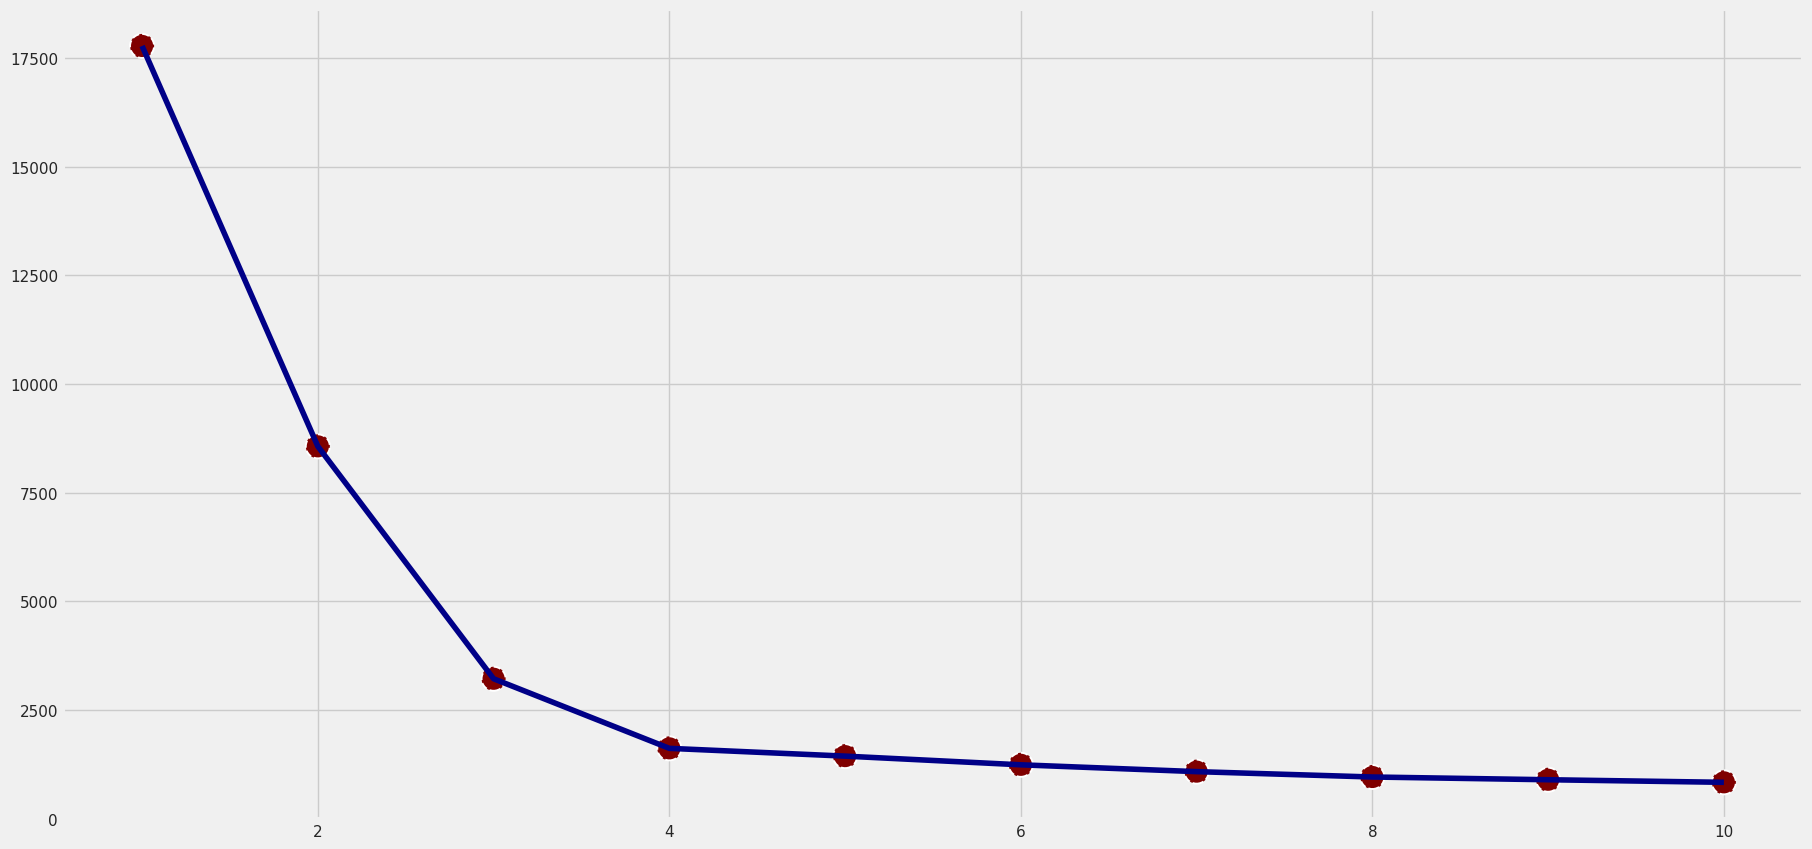

In [ ]:
plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')

In [ ]:
# elbow method : potential jumlah cluster / drop poin 3 atau 4

In [ ]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2,11))
print(range_n_clusters)

[2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
arr_silhouette_score_euclidean = []
for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i).fit(new_df)
    preds = kmeans.predict(new_df)

    score_euclidean = silhouette_score(new_df, preds, metric='euclidean')
    arr_silhouette_score_euclidean.append(score_euclidean)

<Axes: >

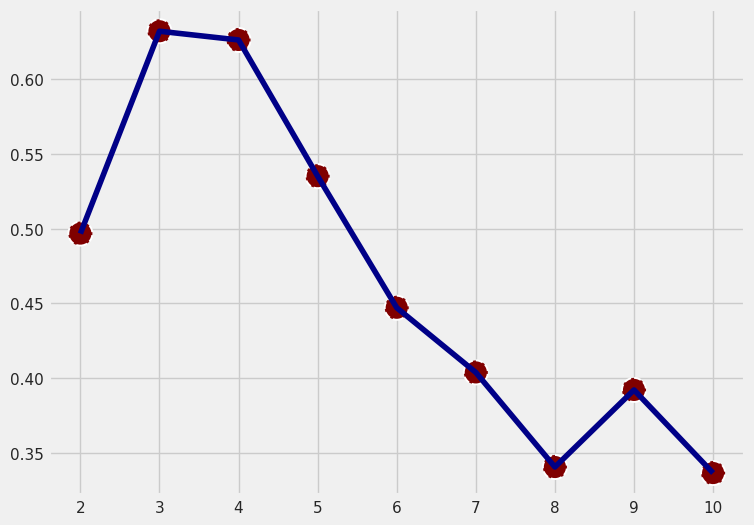

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=range(2,11), y=arr_silhouette_score_euclidean, color='#000087', linewidth = 4)
sns.scatterplot(x=range(2,11), y=arr_silhouette_score_euclidean, s=300, color='#800000',  linestyle='--')

In [ ]:
# silhouette_score = yang paling mendekati 1 yang paling baik : 3 & 4

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(new_df.values)

KMeans(n_clusters=4, random_state=0)

In [ ]:
df['target'] = y

In [ ]:

df['cluster'] = kmeans.labels_

In [ ]:
# df['cluster'] = kmeans.predict(new_data)

In [ ]:
# fig, ax = plt.subplots(figsize=(15,10))
# sns.scatterplot(data=new_df, x='berat', y='tinggi',
#                 hue='target')

<Axes: xlabel='berat', ylabel='tinggi'>

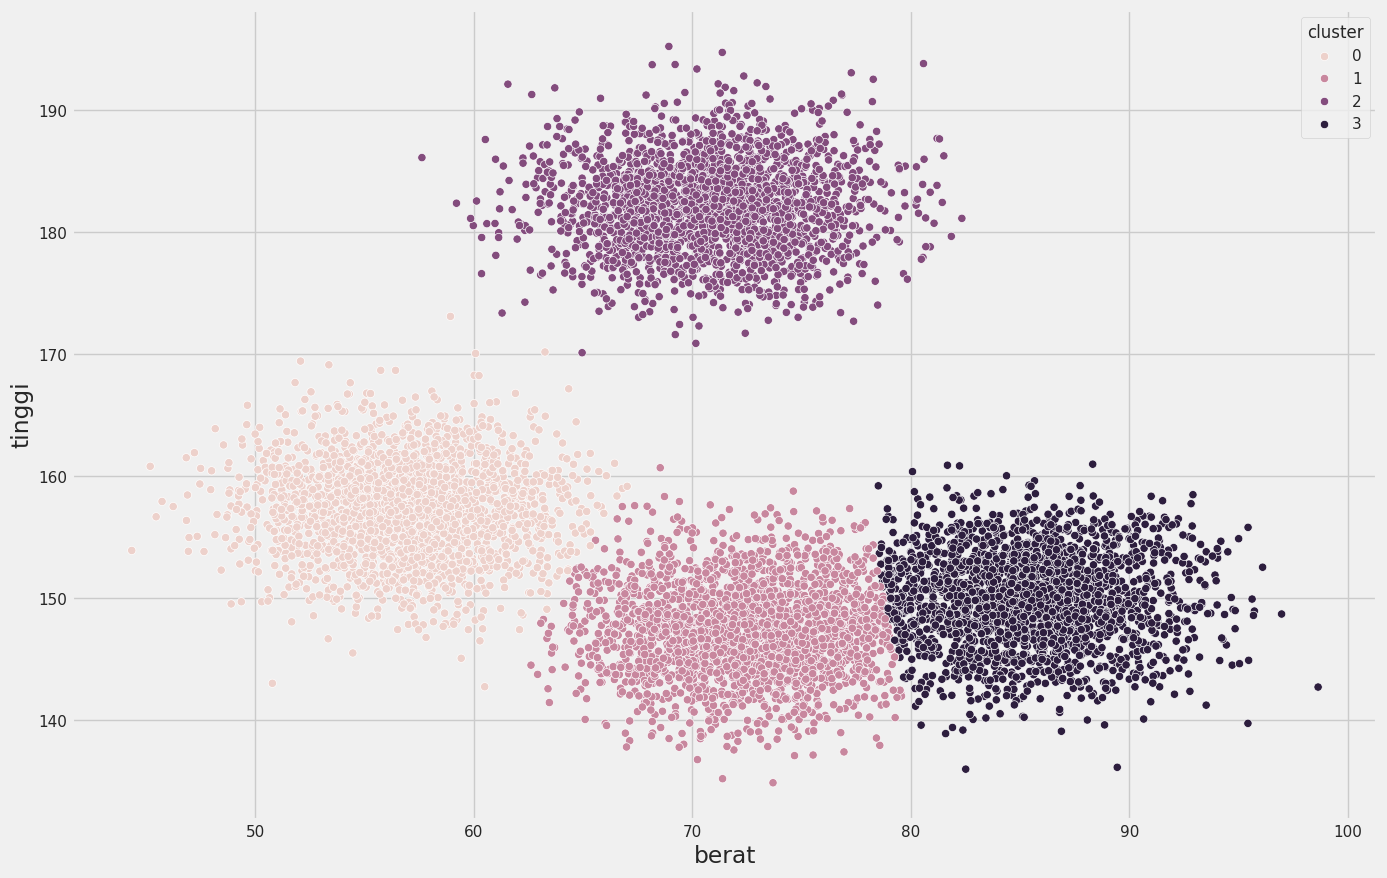

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',
                hue='cluster')

In [ ]:
# mesin hanya memisahkan kelompok 0,1,2,3

In [ ]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

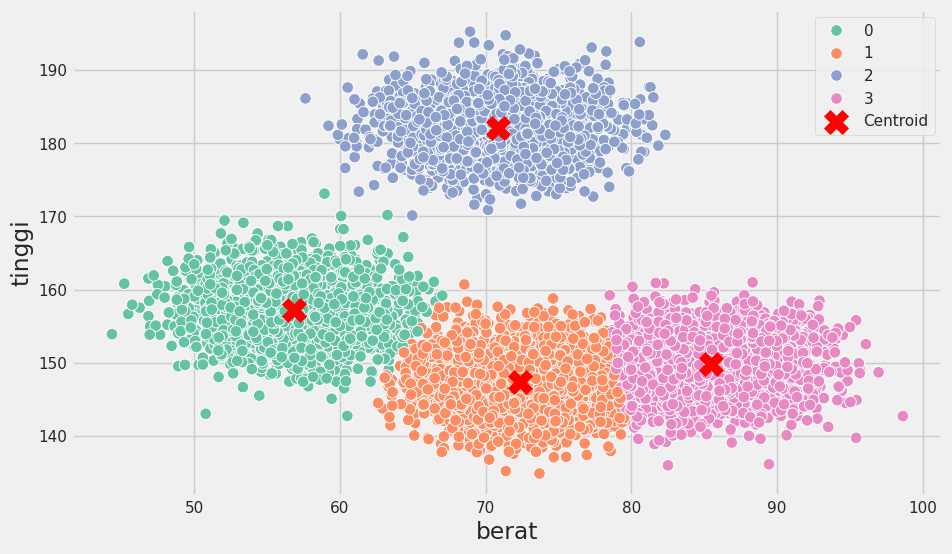

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='cluster',
    palette='Set2',
    s=70,
    ax=ax
)

# Tambahkan centroid
ax.scatter(
    centroids[:, 0],      # berat
    centroids[:, 1],      # tinggi
    c='red',
    s=300,
    marker='X',
    label='Centroid'
)

ax.legend()
plt.show()

coba dengan cluster = 3

In [ ]:
# cluster = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(new_df.values)

KMeans(n_clusters=3, random_state=0)

In [ ]:
df['cluster_3'] = kmeans.labels_

<Axes: xlabel='berat', ylabel='tinggi'>

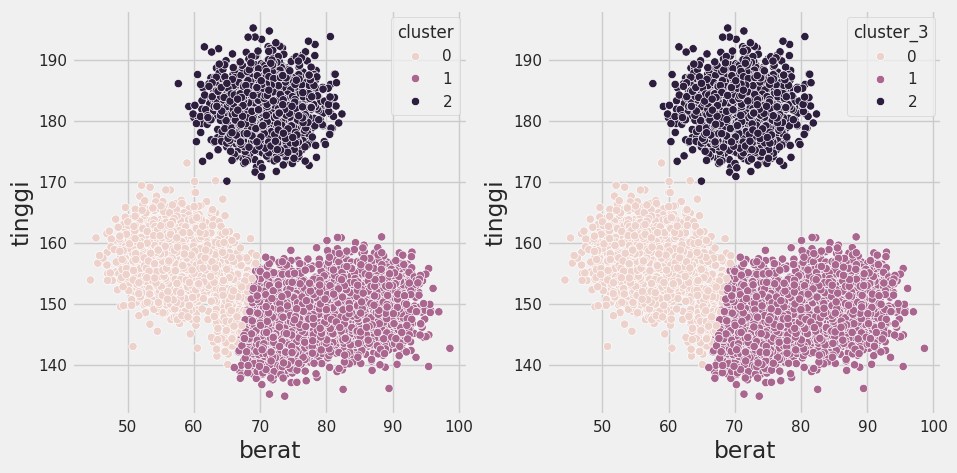

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

sns.scatterplot(data=df, x='berat', y='tinggi',
                hue='cluster', ax=ax[0])

sns.scatterplot(data=df, x='berat', y='tinggi',
                hue='cluster_3', ax=ax[1])

In [ ]:
df.groupby(['cluster']).agg( {
                                'tinggi' : ['mean'],
                                'berat' : ['max']
                              } )

,tinggi,berat
,mean,max
cluster,,
0,157.256287,67.021399
1,147.359503,79.578904
2,182.094451,82.339782
3,149.856603,98.644868


In [ ]:
# cluster 0 : normal -> M
# cluster 1 : fat.   -> L
# cluster 2 : slim.  -> XL
# cluster 3 : obesitas -> XXL

In [ ]:
df.groupby(['cluster_3']).agg( {
                                'tinggi' : ['mean'],
                                'berat' : ['max']
                              } )

# cara mengelompokkan dg baik: jika data nnya mirip2 tinggi dan berat, maka tdk baik
# klo tinggi sama, berat beda gppa / BERBEDA SMUA GPP

,tinggi,berat
,mean,max
cluster_3,,
0,156.427631,69.412431
1,148.567220,98.644868
2,182.094451,82.339782


In [ ]:
# lalu hasil cluster 3 diatas
# cluster 0 : normal
# cluster 1 : fat
# cluster 2 : slim

In [ ]:
#ada 2 opsi dr team data, lalu berdasarkan team bisnis

In [ ]:
### Bandingkan hasil dengan target

<Axes: xlabel='berat', ylabel='tinggi'>

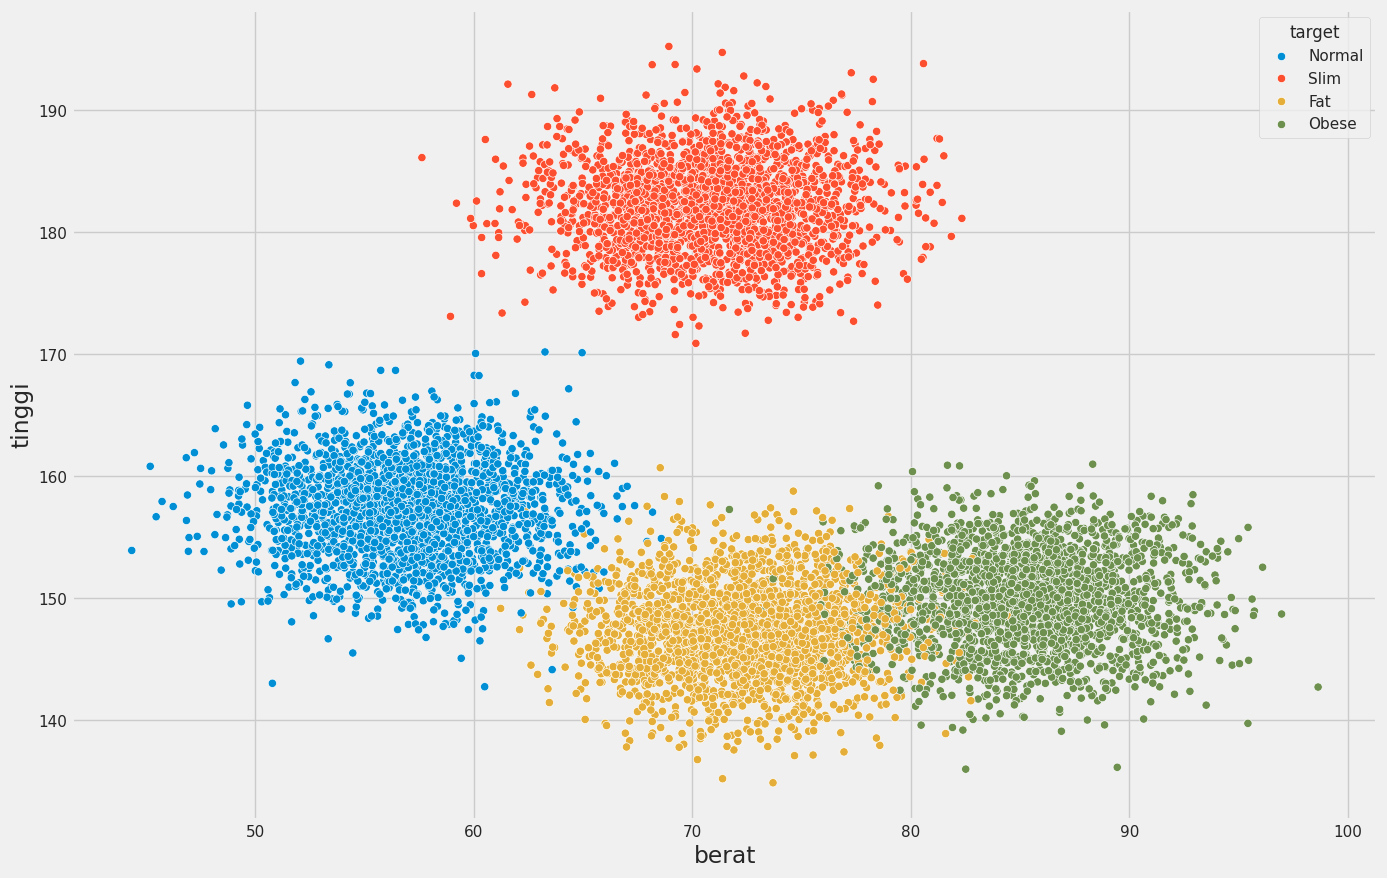

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',
                hue='target')